<a href="https://colab.research.google.com/github/AristidesAntonioOrellanaZelaya/2505442022_ORELLANA_ARISTIDES_CLAVE_E_PARCIAL_4/blob/main/Notebook/Ejercicio_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
url = "https://raw.githubusercontent.com/AristidesAntonioOrellanaZelaya/2505442022_ORELLANA_ARISTIDES_CLAVE_E_PARCIAL_4/refs/heads/main/Data/clave_E_correlacion.csv"

df = pd.read_csv(url)

In [3]:
df.head()

,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,E-C0001,18,1407,7,92.64,7.98,1,3,17.08,578.39
1,E-C0002,29,742,5,61.63,6.81,3,5,16.22,316.79
2,E-C0003,44,1095,9,71.44,8.47,1,7,15.51,633.41
3,E-C0004,51,1036,5,85.68,7.85,3,6,25.30,464.39
4,E-C0005,29,669,4,55.02,6.25,1,2,23.25,251.46


In [5]:
# VALIDACIÓN DEL DATASET

print("DIMENSIONES:")
print(df.shape)

print("\nCOLUMNAS:")
print(df.columns)

print("\nTIPOS DE DATOS:")
print(df.dtypes)

print("\nVALORES NULOS:")
print(df.isnull().sum())

print("\nDUPLICADOS:")
print(df.duplicated().sum())

DIMENSIONES:
(241, 10)

COLUMNAS:
Index(['cliente_id', 'edad', 'ingresos_mensuales', 'frecuencia_compra',
       'ticket_promedio', 'satisfaccion', 'reclamos', 'uso_app',
       'tiempo_respuesta', 'consumo_total'],
      dtype='object')

TIPOS DE DATOS:
cliente_id             object
edad                    int64
ingresos_mensuales      int64
frecuencia_compra       int64
ticket_promedio       float64
satisfaccion          float64
reclamos                int64
uso_app                 int64
tiempo_respuesta      float64
consumo_total         float64
dtype: object

VALORES NULOS:
cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       1
satisfaccion          1
reclamos              0
uso_app               0
tiempo_respuesta      1
consumo_total         0
dtype: int64

DUPLICADOS:
1


In [8]:
# VARIABLES NUMÉRICAS

variables_numericas = df.select_dtypes(include=np.number)

print(variables_numericas.columns)

Index(['edad', 'ingresos_mensuales', 'frecuencia_compra', 'ticket_promedio',
       'satisfaccion', 'reclamos', 'uso_app', 'tiempo_respuesta',
       'consumo_total'],
      dtype='object')


In [9]:
# ESTADÍSTICA DESCRIPTIVA

variables_numericas.describe()

,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
count,241.000000,241.000000,241.000000,240.000000,240.000000,241.000000,241.000000,240.000000,241.000000
mean,37.634855,1059.278008,7.784232,65.582750,7.560000,1.535270,5.688797,21.695417,512.841618
std,9.329583,264.231956,3.335903,15.314243,1.235766,1.524727,1.955398,5.936263,222.898971
min,18.000000,300.000000,1.000000,11.090000,3.180000,0.000000,0.000000,8.530000,90.920000
25%,31.000000,897.000000,6.000000,55.282500,6.770000,0.000000,4.000000,17.370000,378.530000
50%,37.000000,1069.000000,8.000000,66.000000,7.725000,1.000000,6.000000,22.065000,505.050000
75%,44.000000,1211.000000,9.000000,77.225000,8.500000,2.000000,7.000000,25.652500,610.590000
max,59.000000,1820.000000,31.000000,100.590000,10.000000,9.000000,10.000000,37.220000,1890.260000


In [10]:
# DETECCIÓN DE ATIPICOS

for columna in variables_numericas.columns:

    media = variables_numericas[columna].mean()
    desviacion = variables_numericas[columna].std()

    limite_inferior = media - 2 * desviacion
    limite_superior = media + 2 * desviacion

    outliers = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    print(f"\n{columna}")
    print(f"ATIPICOS encontrados: {len(outliers)}")


edad
ATIPICOS encontrados: 11

ingresos_mensuales
ATIPICOS encontrados: 9

frecuencia_compra
ATIPICOS encontrados: 4

ticket_promedio
ATIPICOS encontrados: 8

satisfaccion
ATIPICOS encontrados: 8

reclamos
ATIPICOS encontrados: 9

uso_app
ATIPICOS encontrados: 10

tiempo_respuesta
ATIPICOS encontrados: 10

consumo_total
ATIPICOS encontrados: 6


In [11]:
# MATRIZ DE CORRELACIÓN

correlacion = variables_numericas.corr()

print(correlacion)

                        edad  ingresos_mensuales  frecuencia_compra  \
edad                1.000000           -0.007284          -0.038556   
ingresos_mensuales -0.007284            1.000000           0.236203   
frecuencia_compra  -0.038556            0.236203           1.000000   
ticket_promedio     0.185343            0.604203           0.131095   
satisfaccion       -0.010521            0.055118           0.081625   
reclamos            0.056855            0.018080          -0.042734   
uso_app            -0.027496            0.206300           0.485982   
tiempo_respuesta   -0.023925            0.045327          -0.121644   
consumo_total       0.028779            0.447084           0.893539   

                    ticket_promedio  satisfaccion  reclamos   uso_app  \
edad                       0.185343     -0.010521  0.056855 -0.027496   
ingresos_mensuales         0.604203      0.055118  0.018080  0.206300   
frecuencia_compra          0.131095      0.081625 -0.042734  0.485982 

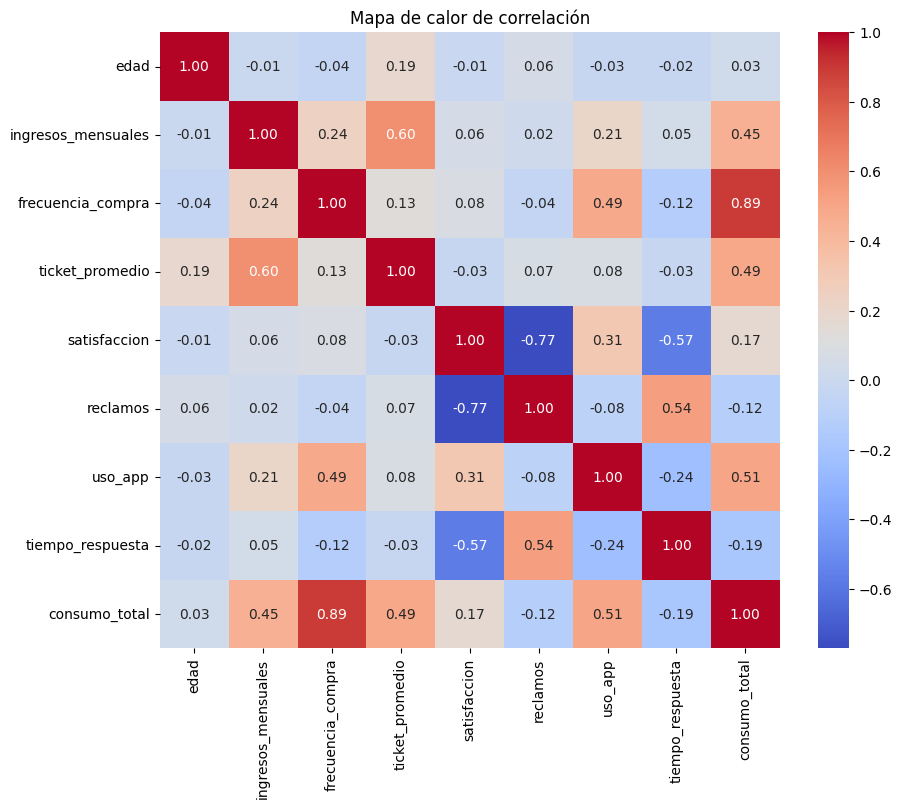

In [12]:
# MAPA DE CALOR

plt.figure(figsize=(10,8))

sns.heatmap(
    correlacion,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Mapa de calor de correlación")

plt.show()

In [13]:
# CORRELACIONES POSITIVAS

corr_positivas = correlacion.unstack()

corr_positivas = corr_positivas.sort_values(ascending=False)

print(corr_positivas.head(10))

edad                edad                  1.000000
ingresos_mensuales  ingresos_mensuales    1.000000
uso_app             uso_app               1.000000
consumo_total       consumo_total         1.000000
tiempo_respuesta    tiempo_respuesta      1.000000
reclamos            reclamos              1.000000
satisfaccion        satisfaccion          1.000000
ticket_promedio     ticket_promedio       1.000000
frecuencia_compra   frecuencia_compra     1.000000
                    consumo_total         0.893539
dtype: float64


In [14]:
# CORRELACIONES NEGATIVAS

corr_negativas = correlacion.unstack()

corr_negativas = corr_negativas.sort_values()

print(corr_negativas.head(10))

reclamos           satisfaccion        -0.770938
satisfaccion       reclamos            -0.770938
                   tiempo_respuesta    -0.572914
tiempo_respuesta   satisfaccion        -0.572914
                   uso_app             -0.237278
uso_app            tiempo_respuesta    -0.237278
consumo_total      tiempo_respuesta    -0.186910
tiempo_respuesta   consumo_total       -0.186910
frecuencia_compra  tiempo_respuesta    -0.121644
tiempo_respuesta   frecuencia_compra   -0.121644
dtype: float64
